In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import astropy
import astropy.cosmology
import matplotlib
from matplotlib import pyplot as plt

import sys
sys.path.insert(0,'../code')
import utils
import correlations
import maps 

%load_ext autoreload
%autoreload 2

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18

matplotlib.rc('text', usetex=False)

# wtheta

### log binning

In [ ]:
G_max = 20.5
theta_edges = np.logspace(-2, 0, 16)
theta = (theta_edges[1:] + theta_edges[:-1]) / 2

z_bins = [(0.0, 1.0), (1.0, 2.0), (2.0, 3.0), (3.0, 4.0)]
wtheta_by_bin = {}
for zmin, zmax in z_bins:
    tag = f'_zmin{zmin}zmax{zmax}'
    tab = Table.read(f'../data/quaia_G{G_max}{tag}.fits')
    tab_rand = Table.read(f'../data/randoms/random_G{G_max}{tag}_10x.fits')
    ra_z, dec_z = tab['ra'], tab['dec']
    ra_rz, dec_rz = tab_rand['ra'], tab_rand['dec']
    wz, DD_z, DR_z, RR_z = correlations.compute_wtheta(
        theta_edges, ra_z, dec_z, ra_rz, dec_rz,
        return_full_results=True, nthreads=16,
    )
    wtheta_by_bin[(zmin, zmax)] = wz
    print(f"Quaia {zmin} < z < {zmax}: N = {len(tab)}")


[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
/Users/ksf/miniconda3/envs/gaiaenv/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD theta time: 0.4940 s
DR theta time: 3.4786 s
RR theta time: 5.7561 s
Total theta time: 9.7317 s
Quaia 0.0 < z < 1.0: N = 324336
DD theta time: 0.6169 s
DR theta time: 10.9744 s
RR theta time: 23.3492 s
Total theta time: 34.9413 s
Quaia 1.0 < z < 2.0: N = 648196
DD theta time: 0.2593 s
DR theta time: 3.0647 s
RR theta time: 5.7166 s
Total theta time: 9.0409 s
Quaia 2.0 < z < 3.0: N = 286508
DD theta time: 0.0871 s
DR theta time: 0.5057 s
RR theta time: 0.3104 s
Total theta time: 0.9036 s
Quaia 3.0 < z < 4.0: N = 35630


In [4]:
# Obscured AGN (red points) - (theta [deg], w(theta))
theta_petter = [0.0045, 0.0055, 0.0075, 0.0090, 0.0105, 0.0125, 0.0160, 0.0200, 0.0280, 0.0400, 0.0600, 0.0900, 0.1300, 0.1800, 0.2400]
wp_petter    = [0.16,   0.22,   0.07,   0.05,   0.06,   0.03,   0.035,  0.022,  0.028,  0.018,  0.012,  0.013,  0.006,  0.004,  0.005]

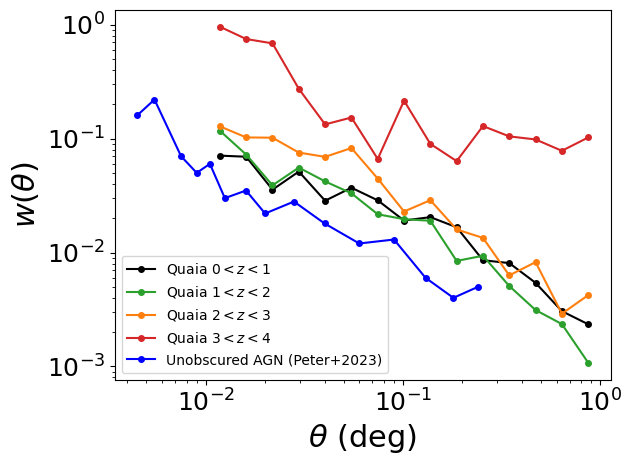

In [5]:
colors = ["black", "tab:green", "tab:orange", "tab:red"]
for (zmin, zmax), color in zip(z_bins, colors):
    wz = wtheta_by_bin[(zmin, zmax)]
    plt.plot(
        theta,
        wz,
        color=color,
        marker="o",
        linestyle="-",
        markersize=4,
        label=rf"Quaia ${zmin:g} < z < {zmax:g}$",
    )
plt.plot(
    theta_petter,
    wp_petter,
    color="blue",
    marker="o",
    linestyle="-",
    markersize=4,
    label="Unobscured AGN (Peter+2023)",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\theta$ (deg)")
plt.ylabel(r"$w(\theta)$")
plt.legend(fontsize=10)


In [6]:
G_max = 20.5
theta_edges = np.logspace(-3, np.log10(5), 27)
theta = (theta_edges[1:] + theta_edges[:-1]) / 2

z_bins = [(0.0, 1.0), (1.0, 2.0), (2.0, 3.0), (3.0, 4.0)]
wtheta_by_bin = {}
for zmin, zmax in z_bins:
    tag = f'_zmin{zmin}zmax{zmax}'
    tab = Table.read(f'../data/quaia_G{G_max}{tag}.fits')
    tab_rand = Table.read(f'../data/randoms/random_G{G_max}{tag}_10x.fits')
    ra_z, dec_z = tab['ra'], tab['dec']
    ra_rz, dec_rz = tab_rand['ra'], tab_rand['dec']
    wz, DD_z, DR_z, RR_z = correlations.compute_wtheta(
        theta_edges, ra_z, dec_z, ra_rz, dec_rz,
        return_full_results=True, nthreads=16,
    )
    wtheta_by_bin[(zmin, zmax)] = wz
    print(f"Quaia {zmin} < z < {zmax}: N = {len(tab)}")


/Users/ksf/miniconda3/envs/gaiaenv/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD theta time: 0.6397 s
DR theta time: 16.0146 s
RR theta time: 64.5373 s
Total theta time: 81.1928 s
Quaia 0.0 < z < 1.0: N = 324336
DD theta time: 4.8746 s
DR theta time: 57.7616 s
RR theta time: 242.3636 s
Total theta time: 305.0016 s
Quaia 1.0 < z < 2.0: N = 648196
DD theta time: 0.7260 s
DR theta time: 11.2192 s
RR theta time: 39.1035 s
Total theta time: 51.0497 s
Quaia 2.0 < z < 3.0: N = 286508
DD theta time: 0.0880 s
DR theta time: 0.4556 s
RR theta time: 1.1721 s
Total theta time: 1.7164 s
Quaia 3.0 < z < 4.0: N = 35630


In [7]:
# Obscured AGN (red points) - (theta [deg], w(theta))
theta_petter = [0.0045, 0.0055, 0.0075, 0.0090, 0.0105, 0.0125, 0.0160, 0.0200, 0.0280, 0.0400, 0.0600, 0.0900, 0.1300, 0.1800, 0.2400]
wp_petter    = [0.16,   0.22,   0.07,   0.05,   0.06,   0.03,   0.035,  0.022,  0.028,  0.018,  0.012,  0.013,  0.006,  0.004,  0.005]

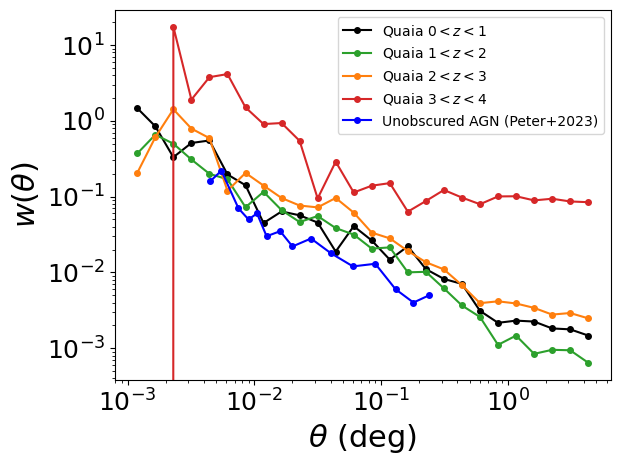

In [8]:
colors = ["black", "tab:green", "tab:orange", "tab:red"]
for (zmin, zmax), color in zip(z_bins, colors):
    wz = wtheta_by_bin[(zmin, zmax)]
    plt.plot(
        theta,
        wz,
        color=color,
        marker="o",
        linestyle="-",
        markersize=4,
        label=rf"Quaia ${zmin:g} < z < {zmax:g}$",
    )
plt.plot(
    theta_petter,
    wp_petter,
    color="blue",
    marker="o",
    linestyle="-",
    markersize=4,
    label="Unobscured AGN (Peter+2023)",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\theta$ (deg)")
plt.ylabel(r"$w(\theta)$")
plt.legend(fontsize=10)


### 0.8<z<2.1

In [3]:
tag_quaia_zclust = '_zmin0.8zmax2.1'
G_max = 20.5
tab_quaia_zclust = Table.read(f'../data/quaia_G{G_max}{tag_quaia_zclust}.fits')
#tab_quaia = Table.read('../data/quaia_G20.5_zsplit2bin0.fits')
print("Columns:", tab_quaia_zclust.columns)
print("N =", len(tab_quaia_zclust))

Columns: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
N = 814561


In [4]:
tab_rand_zclust = Table.read(f'../data/randoms/random_G{G_max}{tag_quaia_zclust}_10x.fits')
print("Columns:", tab_rand_zclust.columns)
print("N =", len(tab_rand_zclust))

Columns: <TableColumns names=('ra','dec','ebv')>
N = 8141884


In [5]:
ra_zclust, dec_zclust = tab_quaia_zclust['ra'], tab_quaia_zclust['dec']
ra_rand_zclust, dec_rand_zclust = tab_rand_zclust['ra'], tab_rand_zclust['dec']

In [6]:
theta_edges_clust = np.logspace(-3, 0, 20)

In [7]:
wtheta_zclust, DD_theta_zclust, DR_theta_zclust, RR_theta_zclust = correlations.compute_wtheta(theta_edges_clust, ra_zclust, dec_zclust, ra_rand_zclust, dec_rand_zclust,
                   return_full_results=True, nthreads=16)

[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
/Users/ksf/miniconda3/envs/gaiaenv/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD theta time: 1.4441 s
DR theta time: 24.8691 s
RR theta time: 57.3269 s
Total theta time: 83.6442 s


In [9]:
theta_clust = (theta_edges_clust[1:] + theta_edges_clust[:-1]) / 2


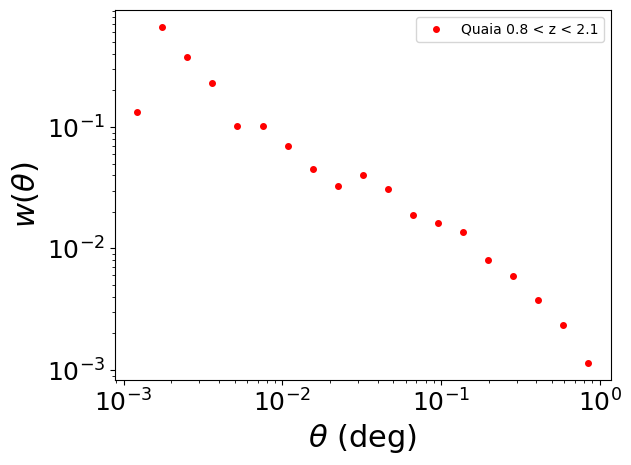

In [10]:
plt.plot(theta_clust, wtheta_zclust, color='red', marker='o', linestyle='none', markersize=4,
        label='Quaia 0.8 < z < 2.1')    
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'$w(\theta)$')
plt.legend(fontsize=10)
#plt.yscale('log')

### linear binning

In [3]:
tag_quaia = '_zmin0.0zmax1.0'
G_max = 20.5
tab_quaia = Table.read(f'../data/quaia_G{G_max}{tag_quaia}.fits')
#tab_quaia = Table.read('../data/quaia_G20.5_zsplit2bin0.fits')
print("Columns:", tab_quaia.columns)
print("N =", len(tab_quaia))

Columns: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
N = 324336


In [4]:
tab_rand = Table.read(f'../data/randoms/random_G{G_max}{tag_quaia}_10x.fits')
print("Columns:", tab_rand.columns)
print("N =", len(tab_rand))

Columns: <TableColumns names=('ra','dec','ebv')>
N = 3242045


In [5]:
ra, dec = tab_quaia['ra'], tab_quaia['dec']
ra_rand, dec_rand = tab_rand['ra'], tab_rand['dec']
theta_edges = np.linspace(0.25, 10, 40)

In [ ]:
wtheta, DD_theta, DR_theta, RR_theta = correlations.compute_wtheta(theta_edges, ra, dec, ra_rand, dec_rand,
                   return_full_results=True, nthreads=16)

[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
/Users/ksf/miniconda3/envs/gaiaenv/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD theta time: 3.4492 s
DR theta time: 86.5821 s
RR theta time: 421.8434 s
Total theta time: 511.8769 s


In [7]:
theta = (theta_edges[1:] + theta_edges[:-1]) / 2


Text(0, 0.5, '$w(\\theta)$')

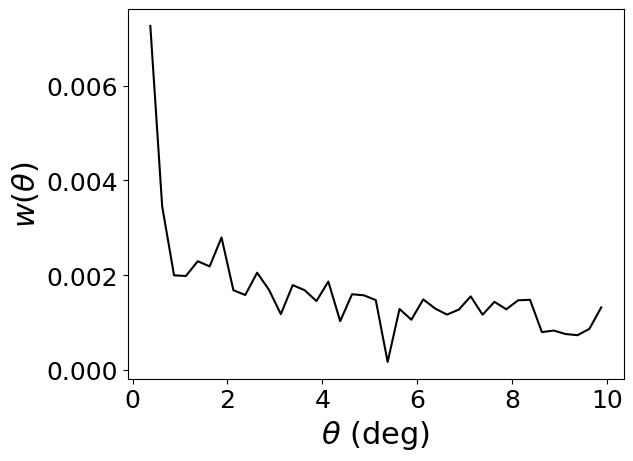

In [8]:
plt.plot(theta, wtheta, color='black')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'$w(\theta)$')
#plt.yscale('log')

In [16]:
tag_quaia = '_zsplit6bin2CIB'
G_max = 20.5
tab_quaia = Table.read(f'../data/quaia_G{G_max}{tag_quaia}.fits')
#tab_quaia = Table.read('../data/quaia_G20.5_zsplit2bin0.fits')
print("Columns:", tab_quaia.columns)
print("N =", len(tab_quaia))
print(f"{np.min(tab_quaia['redshift_quaia']):.2f} < z <  {np.max(tab_quaia['redshift_quaia']):.2f}")

Columns: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
N = 343037
1.00 < z <  1.50


In [18]:
fn_rand = f'../data/randoms/random_G{G_max}{tag_quaia}_10x.fits'
print(fn_rand)
tab_rand = Table.read(fn_rand)
print("Columns:", tab_rand.columns)
print("N =", len(tab_rand))

../data/randoms/random_G20.5_zsplit6bin2CIB_10x.fits
Columns: <TableColumns names=('ra','dec','ebv')>
N = 3428915


In [19]:
ra, dec = tab_quaia['ra'], tab_quaia['dec']
ra_rand, dec_rand = tab_rand['ra'], tab_rand['dec']
theta_edges = np.linspace(0.25, 10, 40)

In [ ]:
wtheta, DD_theta, DR_theta, RR_theta = correlations.compute_wtheta(theta_edges, ra, dec, ra_rand, dec_rand,
                   return_full_results=True, nthreads=16)

/Users/ksf/miniconda3/envs/gaiaenv/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD theta time: 4.8336 s
DR theta time: 95.6802 s
RR theta time: 447.3878 s
Total theta time: 547.9031 s


Text(0, 0.5, '$w(\\theta)$')

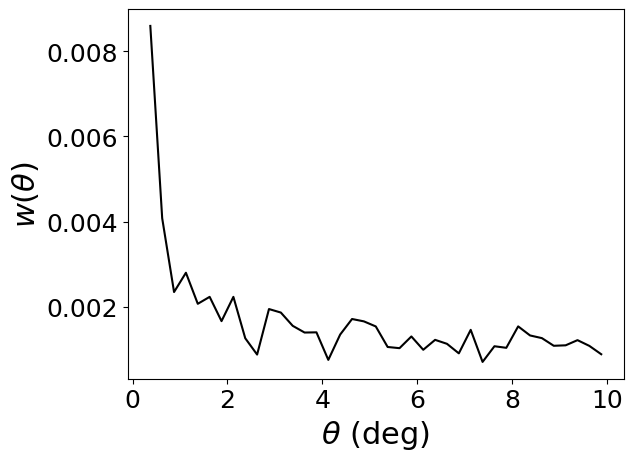

In [21]:
plt.plot(theta, wtheta, color='black')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'$w(\theta)$')
#plt.yscale('log')

# wp

In [4]:
#tag_quaia = '_zsplit6bin2CIB'
tag_quaia = '_zmin1.0zmax2.0'
#tag_quaia = '_zmin0.0zmax1.0'
#tag_quaia = '_zsplit2bin0'
G_max = 20.5
tab_quaia = Table.read(f'../data/quaia_G{G_max}{tag_quaia}.fits')
#tab_quaia = Table.read('../data/quaia_G20.5_zsplit2bin0.fits')
print("Columns:", tab_quaia.columns)
print("N =", len(tab_quaia))
print(f"{np.min(tab_quaia['redshift_quaia']):.2f} < z <  {np.max(tab_quaia['redshift_quaia']):.2f}")

Columns: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
N = 648196
1.00 < z <  2.00


In [5]:
fn_rand = f'../data/randoms/random_G{G_max}{tag_quaia}_10x.fits'
print(fn_rand)
tab_rand = Table.read(fn_rand)
print("Columns:", tab_rand.columns)
print("N =", len(tab_rand))

../data/randoms/random_G20.5_zmin1.0zmax2.0_10x.fits
Columns: <TableColumns names=('ra','dec','ebv')>
N = 6481206


In [6]:
NSIDE_map = 64
fn_selfunc = f'../data/maps/selection_function_NSIDE{NSIDE_map}_G{G_max}{tag_quaia}.fits'
selfunc = hp.read_map(fn_selfunc)
print('Sel func min and max:', np.min(selfunc), np.max(selfunc))

Sel func min and max: 0.0 0.8029652278706577


In [7]:
thresh_selfunc = 0.0
# thresh_selfunc = np.median(selfunc)

In [8]:
_, pixel_indices = maps.get_map(NSIDE_map, tab_quaia['ra'], tab_quaia['dec'])
vals_selfunc = selfunc[pixel_indices]
print(np.median(selfunc))
mask = vals_selfunc > thresh_selfunc
print(f'{len(selfunc[selfunc > np.median(selfunc)])} / {len(selfunc)} = {len(selfunc[selfunc > np.median(selfunc)])/len(selfunc):.2f}')
tab_quaia_masked = tab_quaia[mask]
print(f'{len(tab_quaia)} -> {len(tab_quaia_masked)}')


0.5620297661195913
24576 / 49152 = 0.50
648196 -> 648196


In [9]:
_, pixel_indices_rand = maps.get_map(NSIDE_map, tab_rand['ra'], tab_rand['dec'])
vals_selfunc_rand = selfunc[pixel_indices_rand  ]
mask_rand = vals_selfunc_rand > thresh_selfunc
tab_rand_masked = tab_rand[mask_rand]
print(f'{len(tab_rand)} -> {len(tab_rand_masked)}')


6481206 -> 6481206


In [10]:
ra, dec = tab_quaia_masked['ra'], tab_quaia_masked['dec']
ra_rand, dec_rand = tab_rand_masked['ra'], tab_rand_masked['dec']

In [11]:
rng = np.random.default_rng(42)
z = tab_quaia_masked['redshift_quaia']
z_rand = rng.choice(z, size=len(tab_rand_masked), replace=True)

Text(0, 0.5, '$\\delta$ (deg)')

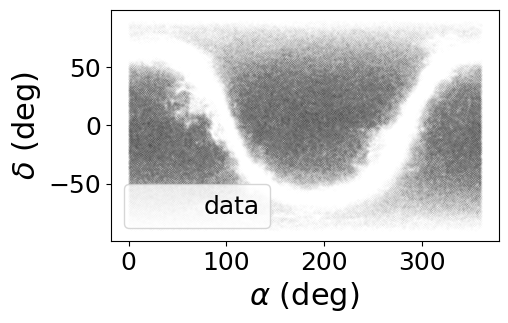

In [16]:
plt.figure(figsize=(5,3))
plt.scatter(ra, dec, c='k', label='data', s=0.01, alpha=0.05)
plt.legend(loc='lower left')
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel(r'$\delta$ (deg)')

Text(0, 0.5, '$\\delta$ (deg)')

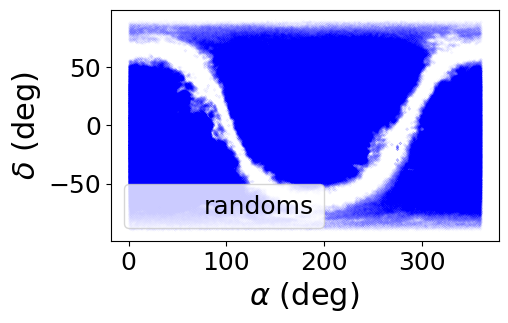

In [17]:
plt.figure(figsize=(5,3))
plt.scatter(ra_rand, dec_rand, c='blue', label='randoms', s=0.01, alpha=0.05)
plt.legend(loc='lower left')
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel(r'$\delta$ (deg)')

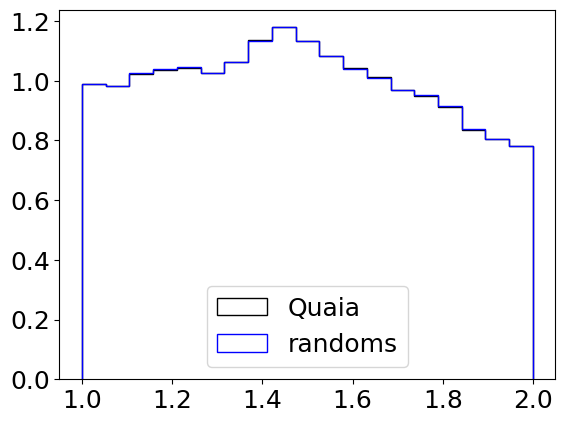

In [18]:
bins = np.linspace(np.min(z), np.max(z), 20)
plt.hist(z, bins=bins, color='k', density=True, histtype='step', label='Quaia')
plt.hist(z_rand, bins=bins, color='blue', density=True, histtype='step', 
         label='randoms')
plt.legend()


In [ ]:
cosmo = astropy.cosmology.Planck18
# Comoving distance in Mpc/h (Corrfunc expects this when is_comoving_dist=True)
# comoving_distance is in Mpc, so to get Mpc/h we need to multiply by h: X Mpc = (X*h) Mpc/h
dist = cosmo.comoving_distance(z).value * cosmo.h
dist_rand = cosmo.comoving_distance(z_rand).value * cosmo.h

In [20]:
print(np.min(ra), np.max(ra))
print(np.min(ra_rand), np.max(ra_rand))
print(np.min(dec), np.max(dec))
print(np.min(dec_rand), np.max(dec_rand))
print(np.min(dist), np.max(dist))
print(np.min(dist_rand), np.max(dist_rand))

0.00020748895937377105 359.9997557589368
1.922507816942698e-05 359.99995500136293
-89.87093590941761 89.97172153446535
-89.95229531772816 89.93768407939929
2297.4862831811497 3591.5189397289773
2297.4862831811497 3591.5189397289773


In [21]:
# rp and pi in Mpc/h (same units as dist passed to compute_wprp)
n_rp_bins = 14
rp_edges_log = np.logspace(np.log10(1), np.log10(200), n_rp_bins+1)
pimax = 100

In [22]:
wp_log, DD_rp_log, DR_rp_log, RR_rp_log = correlations.compute_wprp(rp_edges_log, pimax, ra, dec, dist, 
                                                    ra_rand, dec_rand, dist_rand, 
                                                    return_full_results=True,
                                                    nthreads=16)

[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
/Users/ksf/miniconda3/envs/gaiaenv/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD rp time: 1.2684 s
DR rp time: 38.6463 s
RR rp time: 102.4601 s
Total rp time: 142.3798 s


(0.1, 200.0)

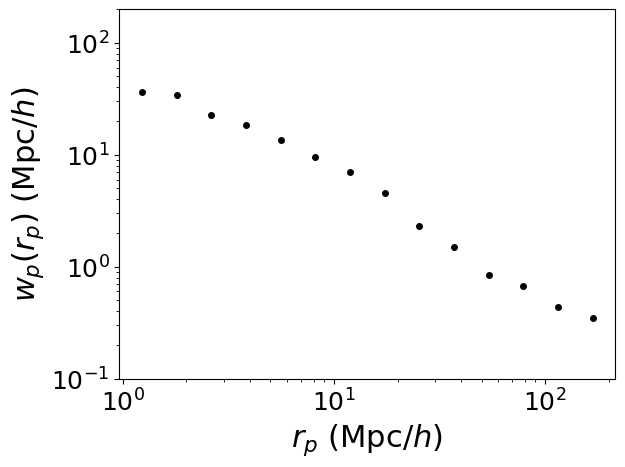

In [ ]:
rp_log = (rp_edges_log[1:] + rp_edges_log[:-1]) / 2
plt.plot(rp_log, wp_log, color='black', marker='o', linestyle='none', markersize=4)
plt.xlabel(r'$r_p$ (Mpc/$h$)')
plt.ylabel(r'$w_p(r_p)$ (Mpc/$h$)')
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-1, 2e2)


(0.001, 200.0)

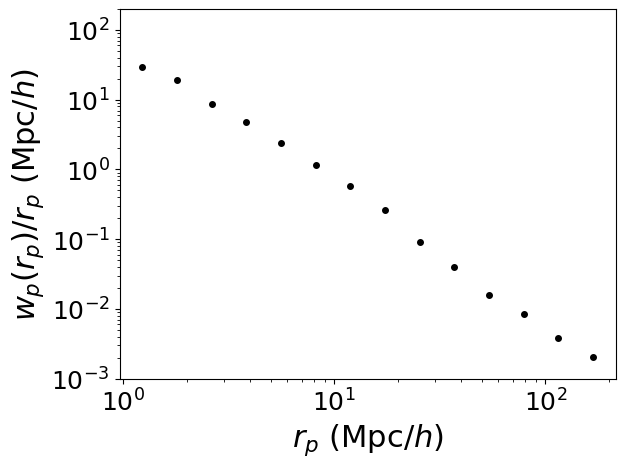

In [30]:
rp_log = (rp_edges_log[1:] + rp_edges_log[:-1]) / 2
plt.plot(rp_log, wp_log/rp_log, color='black', marker='o', linestyle='none', markersize=4)
plt.xlabel(r'$r_p$ (Mpc/$h$)')
plt.ylabel(r'$w_p(r_p) / r_p$ (Mpc/$h$)')
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-3, 2e2)


In [24]:
rp_edges = np.linspace(50, 150, 25)
pimax = 100

In [25]:
wp, DD_rp, DR_rp, RR_rp = correlations.compute_wprp(rp_edges, pimax, ra, dec, dist, 
                                                    ra_rand, dec_rand, dist_rand, 
                                                    return_full_results=True,
                                                    nthreads=16)

DD rp time: 1.7454 s
DR rp time: 16.5822 s
RR rp time: 67.8225 s
Total rp time: 86.1532 s


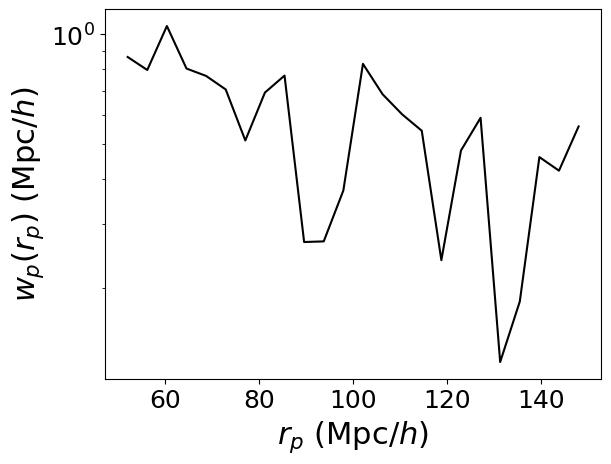

In [26]:
rp = (rp_edges[1:] + rp_edges[:-1]) / 2
plt.plot(rp, wp, color='black')
plt.xlabel(r'$r_p$ (Mpc/$h$)')
plt.ylabel(r'$w_p(r_p)$ (Mpc/$h$)')
plt.yscale('log')


Text(0, 0.5, '$r_p w_p(r_p)$ (Mpc/$h$)')

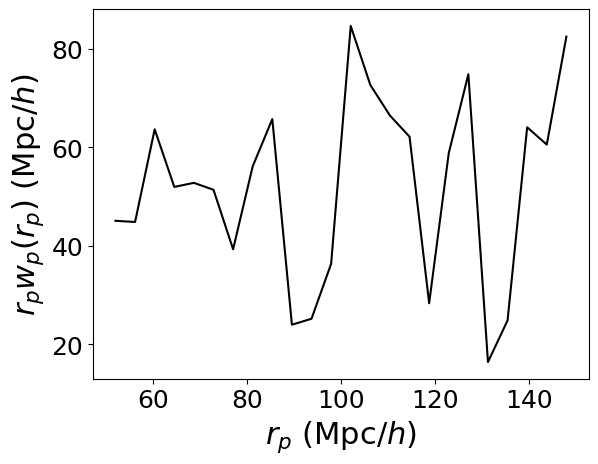

In [27]:
rp = (rp_edges[1:] + rp_edges[:-1]) / 2
plt.plot(rp, rp*wp, color='black')
plt.xlabel(r'$r_p$ (Mpc/$h$)')
plt.ylabel(r'$r_p w_p(r_p)$ (Mpc/$h$)')